In [1]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
# config 
VISION_RADIUS = 4
LOS = 'square360'
GRAZING = True # In case of Bresenham LOS, put grazing walls to False to match the LOS4 and LOS8 visibility maps. This is because Bresenham LOS already accounts for grazing walls in its visibil if required.ty calculation.

Generated Grid:


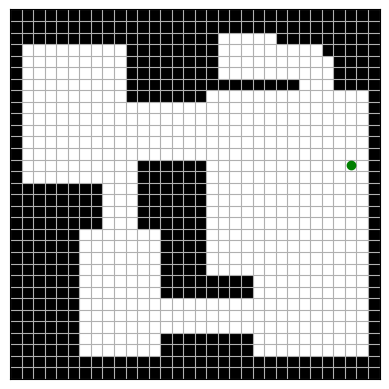

In [ ]:
# Generate a random grid
gen = WRPDataGenerator(32, 32)
grid, start = gen.generate_valid_grid(density=5, clutter_proba=0.0, free_ratio_threshold=0.5)
# grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


In [ ]:
from wrp_solver_suboptimal import solve_wrp_jf, WRPSolverJF

solver_subopt = WRPSolverJF(grid, start, los_type=LOS,  vision_radius=VISION_RADIUS)
path_subopt, cnt_subopt = solve_wrp_jf(solver_subopt, weight = 4, df = 2, heuristic ='tsp')

print("Suboptimal Path Length:", len(path_subopt))

plot_path(grid, path_subopt, start)

In [3]:
def local_astar(start, goal, known_obstacles):
    """
    Standard A* that ONLY routes through known free space.
    """
    def heuristic(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])
        
    neighbors = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}
    
    while open_set:
        current = heapq.heappop(open_set)[1]
        
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.reverse()
            return path # Returns the path EXCLUDING the start node
            
        for dr, dc in neighbors:
            neighbor = (current[0] + dr, current[1] + dc)
            
            if 0 <= neighbor[0] < known_obstacles.shape[0] and 0 <= neighbor[1] < known_obstacles.shape[1]:
                if known_obstacles[neighbor[0], neighbor[1]] == 1.0:
                    continue
                    
                tentative_g_score = g_score[current] + 1
                
                if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    f_score[neighbor] = tentative_g_score + heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))
                    
    return None

def hipps_algorithm(grid, start, max_steps=1000, verbose = True, los_type = LOS, vision_radius = VISION_RADIUS):
    current_pos = start
    path = [current_pos]
    
    # --- THE FIX: MEMORY ARRAYS FOR PLAN COMMITMENT ---
    current_plan = []
    previous_unseen_count = float('inf')
    # --------------------------------------------------
    
    for step in range(max_steps):
        # 1. State Construction
        agent_position = np.zeros_like(grid, dtype=np.float32)
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)
        agent_position[current_pos] = 1.0
        
        grazing_los = get_visibility_map_with_LOS(grid, path, grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=True)
        unseen_map[grazing_los == 1] = 0.0
        visible_walls = grazing_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0
        
        # 2. Your Exact Termination Condition
        explored = 1 - get_LOS4_visibility_map(grid, path, with_last_obstacle=False)
        if (explored == grid).all():
            if verbose:
                print(f"Success! Entire grid explored optimally in {step} steps.")
            break
            
        current_unseen_count = unseen_map.sum()

        # ---------------------------------------------------------
        # EVENT-DRIVEN REPLANNING
        # We ONLY run the U-Net and A* if we have no plan, OR if the fog changed.
        # ---------------------------------------------------------
        if not current_plan or current_unseen_count < previous_unseen_count:
            
            # Update our tracker
            previous_unseen_count = current_unseen_count
            
            # 3. Get U-Net Prediction
            state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
            state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            # with torch.no_grad():
            #     pred = model(state_tensor).cpu().numpy()[0, 0]
                
            # 4. Find all active Frontiers
            frontiers = []
            H, W = grid.shape
            for r in range(H):
                for c in range(W):
                    if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0:
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = r + dr, c + dc
                            if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                                frontiers.append((r, c))
                                break
                                
            if not frontiers:
                if verbose:
                    print(f"Success! Entire polygon explored in {step} steps.")
                break

            # 5. Score Frontiers and COMMIT to the best path
            best_path = None
            best_score = -float('inf')
            
            for f in frontiers:
                if f == current_pos:
                    continue
                    
                 # --- NEW: Information Gain (Guaranteed Area) ---
                # Dynamically simulate vision based on the active LOS settings
                sim_los = get_visibility_map_with_LOS(known_obstacles, [f], grazing_walls=GRAZING, los_type=los_type, vision_radius=vision_radius, with_last_obstacle=False)

                # The gain is strictly the overlap between what the agent *would* see 
                # and the fog that is *currently* unseen.
                simulated_gain = np.sum((sim_los == True) & (unseen_map == 1.0))
                # ------------------------------------------------------

                if simulated_gain == 0:
                    continue  # Skip frontiers that provide no new information

                local_path = local_astar(current_pos, f, known_obstacles)
                
                if local_path is not None and len(local_path) > 0:
                    first_step = local_path[0]
                    # prob = pred[first_step[0], first_step[1]]
                    distance = len(local_path)
                    
                    # --- THE NEW IPP HEURISTIC ---
                    # Weight the U-Net's probability by the immediate mapping gain,
                    # then apply the linear physical distance tax.
                    score = (simulated_gain) / ( distance)
                    # -----------------------------
                    
                    if score > best_score:
                        best_score = score
                        best_path = local_path
                        
            if best_path is None:
                print(f"Agent trapped at step {step}. Frontiers exist but are walled off.")
                break
                
            # SAVE THE ENTIRE PATH TO MEMORY
            current_plan = best_path
            
        # ---------------------------------------------------------
        # THE EXECUTION
        # ---------------------------------------------------------
        # Pop the next step off the plan and physically take it
        next_step = current_plan.pop(0)
        path.append(next_step)
        current_pos = next_step
        
    return path

Success! Entire polygon explored in 53 steps.


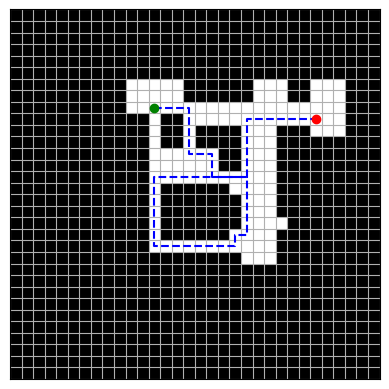

In [81]:

# Algorithm 4: HIPPS
path_hipps = hipps_algorithm(grid, start, los_type=LOS, vision_radius=VISION_RADIUS)
plot_path(grid, path_hipps)

In [4]:
import numpy as np
from PIL import Image

def image_to_grid(path, rows=24, cols=32, light_thresh=152):
    """
    Convert the grid-map image into a (rows x cols) array — EXACT at native 40x30.
      light grey -> 1 (free), dark grey -> 0 (background), yellow -> start (marked 1).
    Returns (grid, start) with start a (row, col) tuple, or None.
    """
    img = np.array(Image.open(path).convert("RGB")).astype(int)
    H, W, _ = img.shape
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    yellow = (R > 150) & (G > 150) & (B < 100)
    start = None
    if yellow.any():
        ys, xs = np.where(yellow)
        start = (int(round(ys.mean() * rows / H)),
                 int(round(xs.mean() * cols / W)))

    grid = np.zeros((rows, cols), dtype=np.int8)
    for r in range(rows):
        for c in range(cols):
            y0, y1 = int(r * H / rows), int((r + 1) * H / rows)
            x0, x1 = int(c * W / cols), int((c + 1) * W / cols)
            block_is_light = (img[y0:y1, x0:x1].mean(axis=2) > light_thresh).mean() > 0.5
            grid[r, c] = 1 if block_is_light else 0

    if start is not None:
        grid[start] = 1

    grid = np.vstack([np.array([[0] * 32] * 4), grid, np.array([[0] * 32] * 4)])
    start = (start[0] + 4, start[1])
    return 1-grid, start

import numpy as np
from PIL import Image

def image_to_grid_24x32(path, mode="anyfree", light_thresh=152):
    """
    Convert the map image to a 24x32 grid (rows x cols).
      light grey -> 1 (free), dark grey -> 0, yellow -> start (marked 1).
    mode="majority": faithful area rounding (tighter borders, may thin 1-cell corridors)
    mode="anyfree" : keep a cell free if any corridor overlaps it (preserves all passages)
    Returns (grid, start).
    """
    img = np.array(Image.open(path).convert("RGB")).astype(int)
    H, W, _ = img.shape
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    # 1) exact native 40x30 grid (aligns with the map's true 16px cells)
    NR, NC = 30, 40
    native = np.zeros((NR, NC), np.int8)
    for r in range(NR):
        for c in range(NC):
            y0, y1 = int(r*H/NR), int((r+1)*H/NR)
            x0, x1 = int(c*W/NC), int((c+1)*W/NC)
            native[r, c] = 1 if (img[y0:y1, x0:x1].mean(2) > light_thresh).mean() > 0.5 else 0

    # 2) downsample 40x30 -> 24x32 with the chosen rounding rule
    rows, cols = 24, 32
    grid = np.zeros((rows, cols), np.int8)
    for r in range(rows):
        for c in range(cols):
            y0, y1 = int(r*NR/rows), int((r+1)*NR/rows)
            x0, x1 = int(c*NC/cols), int((c+1)*NC/cols)
            blk = native[y0:y1, x0:x1]
            grid[r, c] = (blk.mean() > 0.5) if mode == "majority" else int(blk.any())

    # 3) start from the yellow centroid
    yellow = (R > 150) & (G > 150) & (B < 100)
    start = None
    if yellow.any():
        ys, xs = np.where(yellow)
        start = (int(round(ys.mean()*rows/H)), int(round(xs.mean()*cols/W)))
        grid[start] = 1

    grid = np.vstack([np.array([[0] * 32] * 4), grid, np.array([[0] * 32] * 4)])
    start = (start[0] + 4, start[1])
    return 1-grid, start


In [5]:

impath = "data/DungeonMaps/train/10.png"
grid, start = image_to_grid_24x32(impath)
grid1, start1 = image_to_grid(impath)

# grid, start = fit_to(*native_grid("1.png"), 28, 32)   # -> (28, 32) grid, start (14, 22)


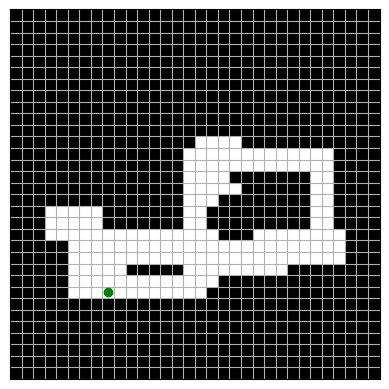

In [9]:
plot_grid(grid, start)

Suboptimal Path Length: 41


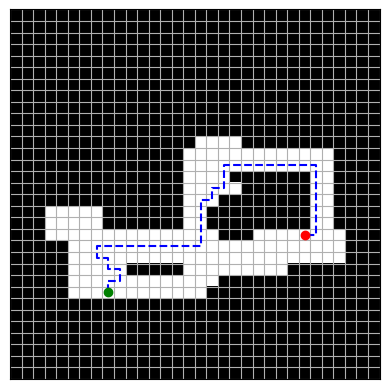

In [6]:
from wrp_solver_suboptimal import solve_wrp_jf, WRPSolverJF

solver_subopt = WRPSolverJF(grid, start, los_type=LOS,  vision_radius=VISION_RADIUS)
path_subopt, cnt_subopt = solve_wrp_jf(solver_subopt, weight = 1, df = 6, heuristic ='tsp')

print("Suboptimal Path Length:", len(path_subopt))

plot_path(grid, path_subopt, start)

Suboptimal Path Length: 41


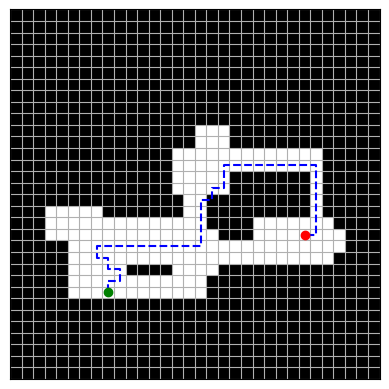

In [11]:
from wrp_solver_suboptimal import solve_wrp_jf, WRPSolverJF

solver_subopt = WRPSolverJF(grid, start, los_type=LOS,  vision_radius=VISION_RADIUS)
path_subopt, cnt_subopt = solve_wrp_jf(solver_subopt, weight = 1, df = 8, heuristic ='tsp')

print("Suboptimal Path Length:", len(path_subopt))

plot_path(grid1, path_subopt, start1)

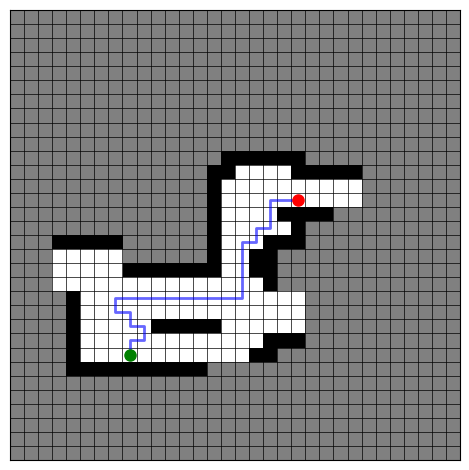

In [24]:
plot_visibility2(grid, path_subopt[:28], vision_radius=VISION_RADIUS, los_type = LOS)

In [21]:
from collections import deque

def all_floor_connected(grid, start):
    rows, cols = len(grid), len(grid[0])
    sr, sc = start

    # change this if your white cells use a different value
    FLOOR = 0

    if grid[sr][sc] != FLOOR:
        return False

    visited = set([(sr, sc)])
    q = deque([(sr, sc)])

    while q:
        r, c = q.popleft()

        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            nr, nc = r + dr, c + dc
            if (0 <= nr < rows and 0 <= nc < cols and
                grid[nr][nc] == FLOOR and
                (nr, nc) not in visited):
                visited.add((nr, nc))
                q.append((nr, nc))

    total_floor = sum(cell == FLOOR for row in grid for cell in row)
    return len(visited) == total_floor

In [28]:
lx = os.listdir("data/DungeonMaps/train/")
avg_path = []

for i in lx:
    if i.endswith(".npy"):
        npdata = np.load("data/DungeonMaps/train/" + i, allow_pickle=True).item()
        grid = npdata["grid"]
        start = npdata["start"]
        path = npdata["path_opt"]
        avg_path.append(len(path))
        assert all_floor_connected(grid, start), f"Grid in {i} has disconnected floor regions!"

print("avg_path_length:", sum(avg_path) / len(avg_path))
print("count:", len(avg_path))

avg_path_length: 42.94825174825175
count: 715


In [19]:
npdata = np.load("data/DungeonMaps/train/img_1837.npy", allow_pickle=True).item()
len(npdata["path_opt"])

65

In [27]:
import time
import pyautogui

print("Mouse jiggler started. Press Ctrl+C in Terminal to stop.")

try:
    while True:
        # Move the mouse 1 pixel to the right
        pyautogui.moveRel(1, 0, duration=0.2)
        # Move the mouse 1 pixel to the left
        pyautogui.moveRel(-1, 0, duration=0.2)
        # Wait 30 seconds before moving again
        time.sleep(30)
except KeyboardInterrupt:
    print("\nMouse jiggler stopped.")


Mouse jiggler started. Press Ctrl+C in Terminal to stop.

Mouse jiggler stopped.
